# Meteorology Forecasting

This notebook documents a complete time-series forecasting pipeline that **predicts meteorological variables 24 hours ahead** across multiple Portuguese cities. It covers:

1. **Pipeline Overview** — how the four pipeline stages connect end-to-end  
2. **Preprocessing** (`01_preprocess.py`) — cleaning, robust CSV resolution, cyclical time and wind encoding  
3. **Feature Engineering** (`02_feature_engineering.py`) — lag features, rolling windows, pressure trends, interaction terms  
4. **Model Design** (`models_04.py`) — LightGBM for temperature, XGBoost Tweedie for rain  
5. **Weekly Block Validation** (`03_weekly_block_validation.py`) — random weekly holdout with temporal gap  
6. **Evaluation & Results** (`05_evaluate.py`) — metrics, plots, and diagnostics  

---

## 1. Pipeline Overview

The full pipeline is orchestrated by `run_pipeline.py`, which calls four scripts in sequence:

```
raw CSV
   │
   ▼
01_preprocess.py              →  data/processed.parquet
   │
   ▼
02_feature_engineering.py     →  data/features.parquet
   │
   ▼
03_weekly_block_validation.py →  results/validation_results.csv
   │
   ▼
05_evaluate.py                →  results/plots/ + results/main_metrics_report.txt
```

Each stage reads the output of the previous one as a Parquet or CSV file. The modular design means any stage can be re-run independently. For example, if only the model changes in `models_04.py`, you only need to re-run `03_weekly_block_validation.py` and `05_evaluate.py`.


In [ ]:
# Run the full pipeline
!python run_pipeline.py

^C



  Running: 01_preprocess.py
Loading CSV …
  Rows: 158,112   Columns: ['location', 'time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'rain', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_highh', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'wind_direction_100m', 'wind_speed_100m', 'pressure_msl', 'surface_pressure']
  Date range: 2025-03-05 00:00:00 → 2026-03-05 23:00:00
  Locations : ['Aveiro', 'Beja', 'Braga', 'Bragança', 'Castelo Branco', 'Coimbra', 'Faro', 'Guarda', 'Leiria', 'Lisboa', 'Portalegre', 'Porto', 'Santarém', 'Setúbal', 'Viana do Castelo', 'Vila Real', 'Viseu', 'Évora']

Saved processed data → c:\Users\gluca\OneDrive\Ambiente de Trabalho\Weather-Prediction\Level_5_Meteorology_Forecasting\data\processed.parquet
  Shape: (158112, 24)
  Columns: ['location', 'time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'rain', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_highh', 'wind_speed_10m', 'win

---
## 2. Preprocessing (`01_preprocess.py`)

The preprocessing step loads the raw meteorology dataset, sanitizes text fields, encodes cyclical variables, and writes a clean Parquet file.

### 2.1 Robust CSV path resolution

The script resolves the input CSV from multiple candidate locations/names used in this repository:

- `../data/meteorology_dataset.csv`
- `../meteorology_dataset.csv`
- `../metherology_dataset.csv`

If none is found, it raises a clear `FileNotFoundError` listing checked paths.

### 2.2 Time and ordering

Rows are sorted by `location` and `time`, ensuring deterministic lag and rolling computations downstream.

### 2.3 Cyclical encoding

Cyclical variables are projected with sine/cosine to preserve periodic continuity:

- Hour: `hour_sin`, `hour_cos`
- Month: `month_sin`, `month_cos`
- Wind direction (10m and 100m): `wind_dir_*_sin`, `wind_dir_*_cos`

This avoids discontinuities such as hour 23 vs hour 0 and 359° vs 1°.

### 2.4 Saved output

The stage writes `data/processed.parquet` with clean, model-ready columns and preserved hourly granularity.

In [38]:
# 01_preprocess.py — Core logic (abridged)

from pathlib import Path
import os
import numpy as np
import pandas as pd


def resolve_base_dir() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "Level_5_Meteorology_Forecasting",
    ]
    for candidate in candidates:
        if (candidate / "run_pipeline.py").exists():
            return candidate
    return cwd


BASE_DIR = resolve_base_dir()
CSV_CANDIDATES = [
    BASE_DIR.parent / "data" / "meteorology_dataset.csv",
    BASE_DIR.parent / "meteorology_dataset.csv",
    BASE_DIR.parent / "metherology_dataset.csv",
]


def resolve_raw_csv() -> Path:
    for path in CSV_CANDIDATES:
        if path.exists():
            return path
    checked = "\n  - ".join(str(path) for path in CSV_CANDIDATES)
    raise FileNotFoundError(f"No meteorology CSV found. Checked:\n  - {checked}")


def preprocess(raw_csv_path: str, out_parquet_path: str):
    df = pd.read_csv(raw_csv_path)
    df.columns = df.columns.str.strip()
    df["location"] = df["location"].str.strip()

    df["time"] = pd.to_datetime(df["time"].str.strip())
    df = df.sort_values(["location", "time"]).reset_index(drop=True)

    hour = df["time"].dt.hour
    month = df["time"].dt.month

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)
    df["day_of_year"] = df["time"].dt.day_of_year

    for level in ["10m", "100m"]:
        col = f"wind_direction_{level}"
        df[f"wind_dir_{level}_sin"] = np.sin(np.deg2rad(df[col]))
        df[f"wind_dir_{level}_cos"] = np.cos(np.deg2rad(df[col]))

    df = df.drop(columns=["wind_direction_10m", "wind_direction_100m"])
    df.to_parquet(out_parquet_path, index=False)


print(f"Notebook base directory: {BASE_DIR}")
print(f"Resolved raw CSV: {resolve_raw_csv()}")

Notebook base directory: c:\Users\gluca\OneDrive\Ambiente de Trabalho\Weather-Prediction\Level_5_Meteorology_Forecasting
Resolved raw CSV: c:\Users\gluca\OneDrive\Ambiente de Trabalho\Weather-Prediction\data\meteorology_dataset.csv


---
## 3. Feature Engineering (`02_feature_engineering.py`)

All feature transformations are computed per location group to avoid leakage across cities.

### 3.1 Targets (+24h horizon)

```python
grp["target_temperature_2m"] = grp["temperature_2m"].shift(-24)
grp["target_rain"] = grp["rain"].shift(-24)
```

Each row at time `t` predicts observed values at `t + 24h`.

### 3.2 Lag sets

Current lag design is variable-specific:

- Temperature lags: `[24, 48, 72, 96, 120, 168]`
- Rain lags: `[1, 12, 24, 48, 72, 96, 120, 168]`
- Pressure lags: `[1, 6, 24, 48, 72]`
- Auxiliary lags for wind/humidity/cloud: `[1, 6, 24, 48, 72]`
- Additional cloud precursor lags:
  - `cloud_cover_mid_lag_12h`, `cloud_cover_mid_lag_24h`
  - `cloud_cover_highh_lag_12h`, `cloud_cover_highh_lag_24h`

### 3.3 Rolling features

Rolling windows use only data up to time `t`:

- Temperature: `temp_roll_6h`, `temp_roll_24h`, `temp_roll_72h`
- Rain accumulation: `rain_roll_24h`, `rain_roll_72h`, `rain_roll_168h`
- Pressure/humidity/cloud smoothing: `pressure_roll_24h`, `humidity_roll_3h`, `cloud_roll_3h`

### 3.4 Pressure trend features

Synoptic trend signals:

- `pressure_trend_3h`
- `pressure_trend_6h`
- `pressure_trend_12h`
- `pressure_trend_24h`

### 3.5 Interactions and location encoding

- `temp_dew_spread`
- `pressure_diff`
- `wind_shear`
- `location_id` encoded by sorted location order for reproducibility

In [39]:
# 02_feature_engineering.py — Core logic (abridged)

import pandas as pd

RAW_TO_TARGET = {
    "temperature_2m": "target_temperature_2m",
    "rain": "target_rain",
}

TEMP_LAG_SHIFTS = [24, 48, 72, 96, 120, 168]
RAIN_LAG_SHIFTS = [1, 12, 24, 48, 72, 96, 120, 168]
PRESSURE_LAG_SHIFTS = [1, 6, 24, 48, 72]
AUX_LAG_SHIFTS = [1, 6, 24, 48, 72]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    locations_sorted = sorted(df["location"].unique())
    loc_to_id = {loc: i for i, loc in enumerate(locations_sorted)}
    groups = []

    for loc, grp in df.groupby("location", sort=False):
        grp = grp.copy().sort_values("time").reset_index(drop=True)

        for raw_col, tgt_col in RAW_TO_TARGET.items():
            grp[tgt_col] = grp[raw_col].shift(-24)

        for s in TEMP_LAG_SHIFTS:
            grp[f"temperature_2m_lag_{s}h"] = grp["temperature_2m"].shift(s)

        for s in RAIN_LAG_SHIFTS:
            grp[f"rain_lag_{s}h"] = grp["rain"].shift(s)

        for s in PRESSURE_LAG_SHIFTS:
            grp[f"pressure_msl_lag_{s}h"] = grp["pressure_msl"].shift(s)

        for s in AUX_LAG_SHIFTS:
            grp[f"wind_speed_10m_lag_{s}h"] = grp["wind_speed_10m"].shift(s)
            grp[f"relative_humidity_lag_{s}h"] = grp["relative_humidity_2m"].shift(s)
            grp[f"cloud_cover_lag_{s}h"] = grp["cloud_cover"].shift(s)

        for s in [12, 24]:
            grp[f"cloud_cover_mid_lag_{s}h"] = grp["cloud_cover_mid"].shift(s)
            grp[f"cloud_cover_highh_lag_{s}h"] = grp["cloud_cover_highh"].shift(s)

        grp["rain_roll_168h"] = grp["rain"].rolling(168, min_periods=1).sum()
        grp["pressure_trend_24h"] = grp["pressure_msl"] - grp["pressure_msl"].shift(24)
        grp["location_id"] = loc_to_id[loc]

        groups.append(grp)

    result = pd.concat(groups, ignore_index=True)
    result = result.dropna(subset=list(RAW_TO_TARGET.values())).reset_index(drop=True)
    return result

---
## 4. Model Design (`models_04.py`)

Each target uses a dedicated model:

### 4.1 Temperature: LightGBM Regressor

`target_temperature_2m` is modeled with LightGBM (`num_leaves=63`) to capture non-linear weather interactions while keeping training fast.

### 4.2 Rain: XGBoost Tweedie Regressor

`target_rain` uses XGBoost with Tweedie objective:

- `objective="reg:tweedie"`
- `tweedie_variance_power=1.3`

This setting is tuned for sparse, bursty **hourly** rain behavior. Predictions are clipped at zero, and values below `0.1 mm` are treated as zero rain in post-processing.

### 4.3 Why two model families?

Temperature and rain have distinct distributions:

- Temperature: smoother, strongly seasonal and diurnal
- Rain: zero-inflated, highly skewed, event-driven

Using separate models avoids forcing one statistical assumption onto both targets.

In [ ]:
# models_04.py — Model factory (abridged)

import lightgbm as lgb
import xgboost as xgb

TARGETS = ["target_temperature_2m", "target_rain"]

TARGET_SHORT = {
    "target_temperature_2m": "Temperature (C)",
    "target_rain": "Rain (mm)",
}


def get_model(target: str):
    if target == "target_temperature_2m":
        return lgb.LGBMRegressor(
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=63,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.05,
            reg_lambda=0.1,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )

    if target == "target_rain":
        return xgb.XGBRegressor(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            objective="reg:tweedie",
            tweedie_variance_power=1.3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )

    raise ValueError(f"Unknown target: {target}")

---
## 5. Weekly Block Validation (`03_weekly_block_validation.py`)

The validation stage uses **random weekly block holdout with temporal gap**.

### Why this strategy?

A strict early expanding-window split can under-represent some seasonal regimes depending on where the dataset starts. In this dataset, that especially hurts rain evaluation because the wet season is concentrated in specific months.

Weekly blocked validation solves that by sampling held-out weeks across the year while still protecting against short-range leakage.

### Validation procedure

1. Create a weekly identifier from each timestamp using ISO `year_week`
2. Randomly assign 25% of weekly blocks to validation
3. Remove adjacent weeks from training using a 1-week temporal gap
4. Train one model per target on the remaining safe training weeks
5. Evaluate on the held-out validation weeks

### What the temporal gap protects against

The 1-week gap reduces two important leakage risks:

- **Lag leakage**: a validation row with long lags such as `lag_168h` should not read directly from a neighbouring training week
- **Target leakage**: the `shift(-24)` label near a training/validation boundary should not point into the held-out week

### Current config

- `RANDOM_SEED = 42`
- `TEST_FRACTION = 0.25`
- `GAP_WEEKS = 1`

This is a **blocked temporal holdout validation**, not rolling walk-forward evaluation.


In [ ]:
# 03_weekly_block_validation.py — Weekly blocked validation (abridged)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

RANDOM_SEED = 42
TEST_FRACTION = 0.25
GAP_WEEKS = 1
NON_FEATURE_COLS = {"target_temperature_2m", "target_rain", "time", "location"}


def assign_week_ids(df: pd.DataFrame) -> pd.Series:
    iso = df["time"].dt.isocalendar()
    return iso["year"].astype(str) + "_" + iso["week"].astype(str).str.zfill(2)


def build_train_validation_split(df: pd.DataFrame):
    rng = np.random.default_rng(RANDOM_SEED)
    df = df.copy()
    df["_week_id"] = assign_week_ids(df)

    all_weeks = sorted(df["_week_id"].unique())
    week_idx = {w: i for i, w in enumerate(all_weeks)}

    n_validation = max(1, int(len(all_weeks) * TEST_FRACTION))
    validation_weeks = set(rng.choice(all_weeks, size=n_validation, replace=False))

    blocked = set()
    for validation_week in validation_weeks:
        idx = week_idx[validation_week]
        for delta in range(1, GAP_WEEKS + 1):
            if idx - delta >= 0:
                blocked.add(all_weeks[idx - delta])
            if idx + delta < len(all_weeks):
                blocked.add(all_weeks[idx + delta])

    safe_train_weeks = set(all_weeks) - validation_weeks - blocked
    train_df = df[df["_week_id"].isin(safe_train_weeks)].drop(columns=["_week_id"])
    validation_df = df[df["_week_id"].isin(validation_weeks)].drop(columns=["_week_id"])
    return train_df, validation_df


def evaluate_validation_split(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
    train_df, validation_df = build_train_validation_split(df)

    X_train, X_valid = train_df[feature_cols], validation_df[feature_cols]

    # Train one model per target, predict held-out weeks, compute MAE
    return mean_absolute_error


---
## 6. Evaluation and Results (`05_evaluate.py`)

### 6.1 Summary Metrics (current run)

The latest run was evaluated over **39,312 rows** with **1 validation split** (`step=0`).

| Target | MAE | RMSE | R2 | Pearson r | Bias |
|---|---:|---:|---:|---:|---:|
| Temperature 2m (°C) | **1.8281** | 2.3402 | 0.8473 | 0.9250 | +0.5283 |
| Rain (mm) | **0.1295** | 0.5168 | 0.0203 | 0.2178 | -0.0859 |

Global metrics:

- Global MAE: **0.9788**
- Score (2 targets): **14.8634**
- Competition-equivalent score (5/17): **37.1586**

Score formula:

```text
Score = (2.5 / (1 + MAE_global)) * (N_targets / 17) * 100
```

### 6.2 Temperature Forecast

Temperature performance is strong and stable:

- MAE = **1.828°C**
- R2 = **0.847**
- Pearson correlation = **0.925**
- Bias = **+0.528°C** (systematic warm-side overestimation)

Interpretation:

- The model captures most of daily and seasonal variation.
- The positive bias suggests a calibration opportunity (post-hoc correction or objective tuning).

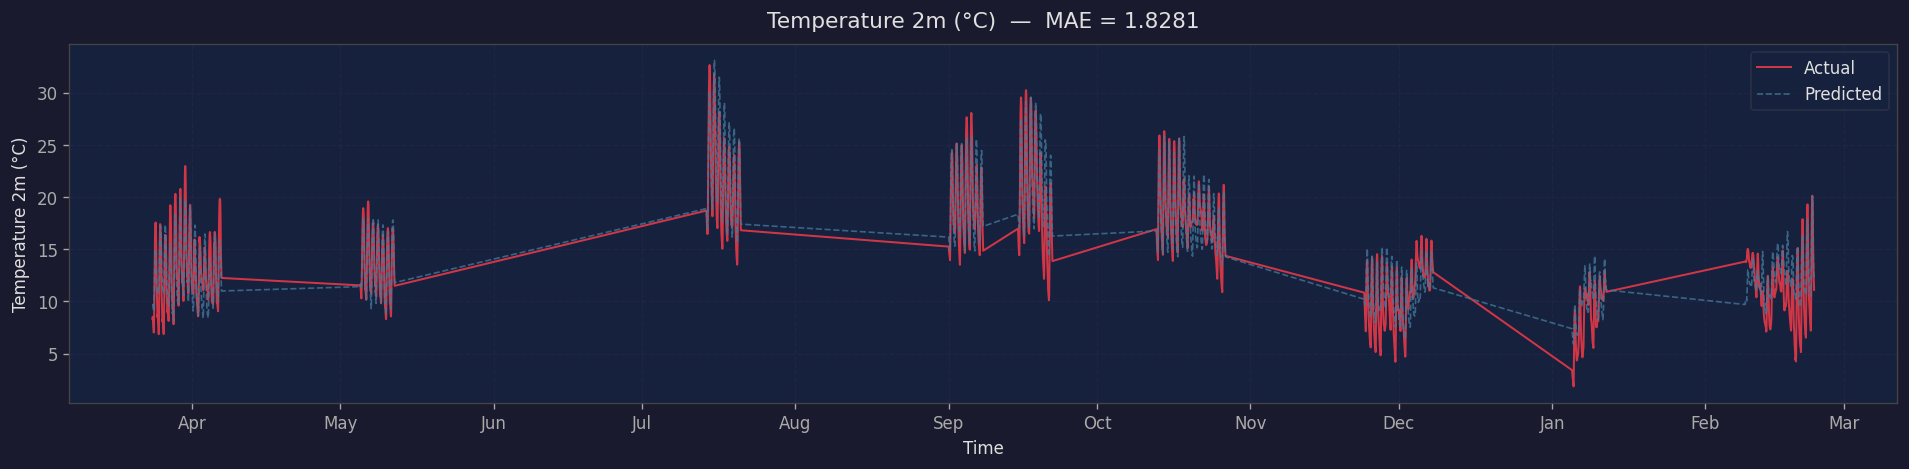

In [ ]:
from pathlib import Path
from IPython.display import Image, display

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

img = _plots_dir() / 'target_temperature_2m_actual_vs_pred.png'
display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.3 Rain Forecast

Rain remains the hardest variable due to sparse and spiky hourly behavior:

- MAE = **0.1295 mm**
- R2 = **0.0203**
- Pearson correlation = **0.2178**
- Bias = **-0.0859 mm** (underestimation tendency)

Interpretation:

- The model behaves conservatively, reducing false drizzle.
- Intense events are still under-predicted in magnitude.
- Feature/training changes improved MAE while keeping realistic non-zero-rate behavior.

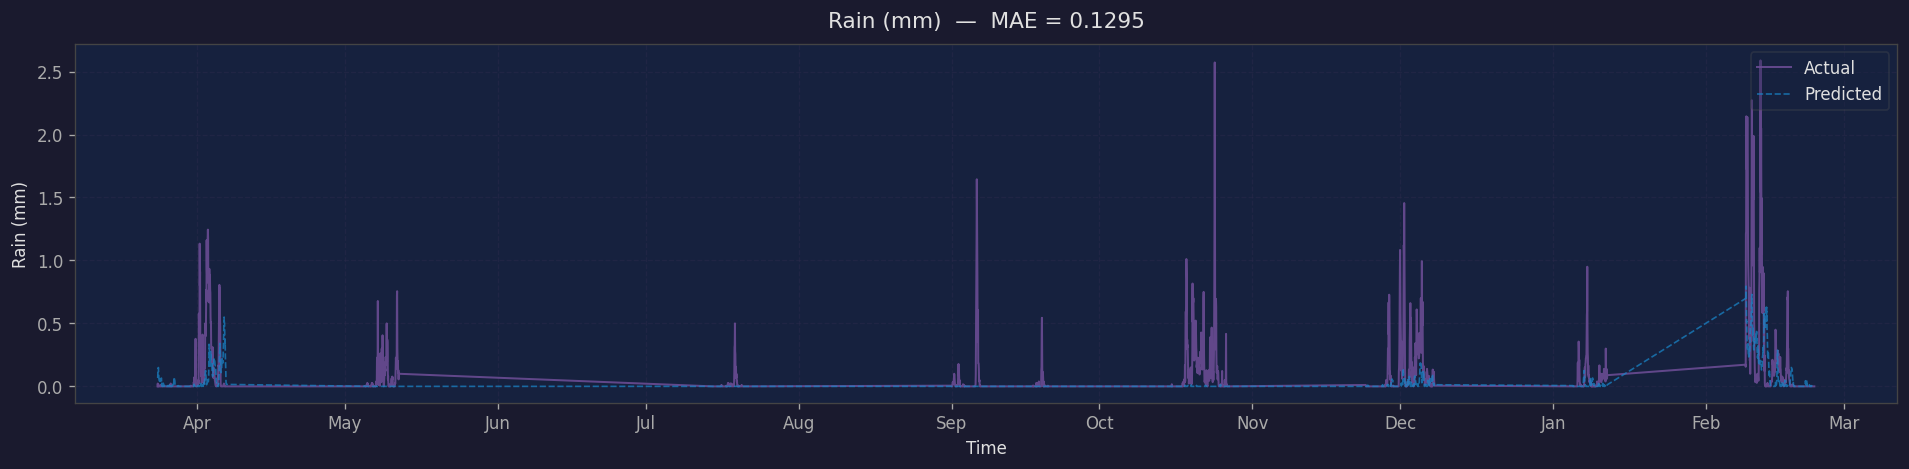

In [ ]:
from pathlib import Path
from IPython.display import Image, display

def _plots_dir():
    local = Path.cwd() / 'results' / 'plots'
    if local.exists():
        return local
    nested = Path.cwd() / 'Level_5_Meteorology_Forecasting' / 'results' / 'plots'
    if nested.exists():
        return nested
    return Path('results') / 'plots'

img = _plots_dir() / 'target_rain_actual_vs_pred.png'
display(Image(filename=str(img))) if img.exists() else print(f'Image not found: {img}')

### 6.4 Rain Diagnostics

The evaluation report includes a dedicated diagnostics section for the rain target:

| Diagnostic | Value | Interpretation |
|---|---|---|
| Actual non-zero rate | 18.7% | Rain falls in about 1 in 5 hours |
| Predicted non-zero rate | 12.2% | Model predicts rain less often than it occurs — conservative |
| Pred mean when actual = 0 | 0.021 mm | Low false-drizzle prediction — good dry-hour behaviour |
| Pred mean when actual > 0 | 0.091 mm | Severe underestimation during rainy hours |
| Max actual rain | 11.6 mm | Strong event present in the holdout split |
| Max predicted rain | 2.21 mm | Model still compresses heavy-event magnitude |

The Tweedie model remains conservative: it reduces false alarms on dry hours, but still underestimates stronger precipitation events. The new feature set improved overall rain MAE, but peak-rain calibration is still the main open weakness.


---
## 7. Conclusions

### What Worked Well
- **LightGBM for temperature** remains strong, reaching MAE = 1.828 and R² = 0.847 on the current weekly blocked validation split.
- **XGBoost Tweedie for rain** improved rain MAE to 0.1295 mm while keeping low false-drizzle behaviour.
- **Pressure trends, long-horizon lags, and rain accumulation features** added useful meteorological signal, especially for rain.
- **Robust CSV path resolution** makes preprocessing resilient to the dataset naming and folder layout used in this repository.
- **Model caching** keeps repeated interface predictions fast after the first training pass.

### Current Limitations
- The validation protocol is a **weekly blocked holdout with temporal gap**, so it measures held-out temporal generalisation rather than rolling deployment drift.
- Rain prediction is still conservative and underestimates heavier events.
- The temperature model shows a **warm-side bias** of about +0.53°C, which suggests room for calibration.
